$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
$$

INSERT_setup_intro

INSERT_problem_a

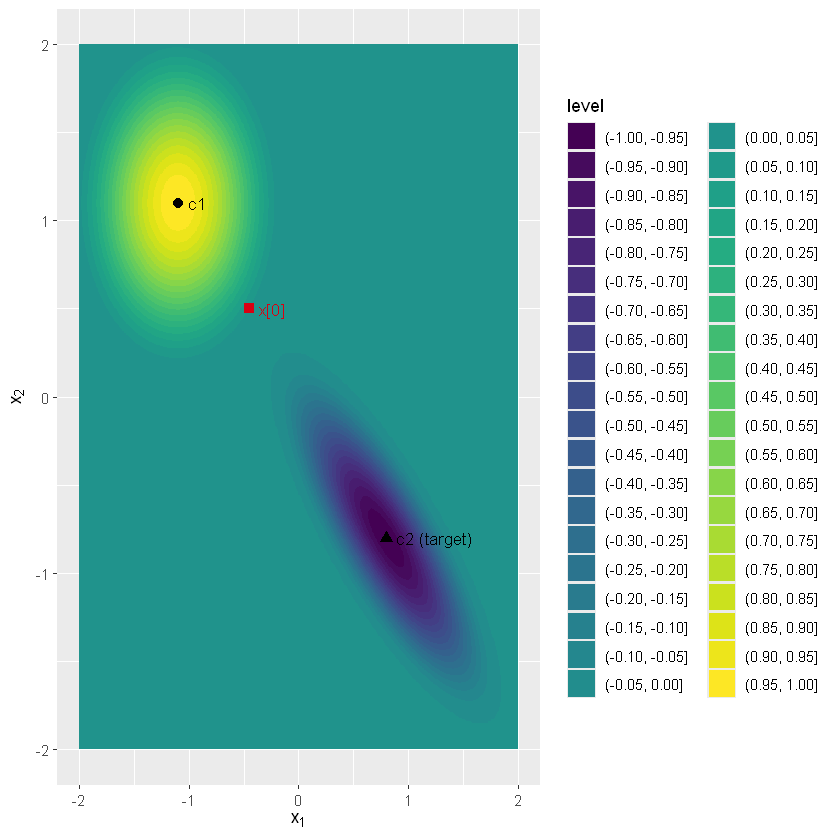

In [1]:
#| label: setup_data
library(ggplot2)

c1 <- c(-1.1, 1.1)
c2 <- c(0.8, -0.8)
S2 <- matrix(c(1.1, -0.9, -0.9, 1.1), nrow = 2)
S2_inv <- solve(S2)

rho   <- function(u) ifelse(abs(u) < 1, (1 - u^2)^2, 0)
dist1 <- function(x) sqrt(sum((x - c1)^2))   # Euclidean (S1 = I)
dist2 <- function(x) sqrt((x - c2) %*% S2_inv %*% (x - c2))   # Mahalanobis

# w_1 = +1, w_2 = -1
f <- function(x) rho(dist1(x)) - rho(dist2(x))

# Surface plot on [-2, 2] x [-2, 2]
x <- seq(-2, 2, by = 0.01)
xx <- expand.grid(X1 = x, X2 = x)
fxx <- apply(xx, 1, f)
df_grid <- data.frame(xx, fxx = fxx)

cont_plot <- ggplot(df_grid, aes(x = X1, y = X2, z = fxx)) +
  geom_contour_filled(binwidth = 0.05) +
  xlab(expression(x[1])) +
  ylab(expression(x[2])) +
  # landmarks: positive-bump center, negative-bump center (target), start point
  annotate("point", x = c1[1], y = c1[2], color = "black", size = 2.5) +
  annotate("text",  x = c1[1], y = c1[2], label = "  c1", hjust = 0,
           color = "black", size = 3.5) +
  annotate("point", x = c2[1], y = c2[2], color = "black",
           size = 2.5, shape = 17) +
  annotate("text",  x = c2[1], y = c2[2], label = "  c2 (target)", hjust = 0,
           color = "black", size = 3.5) +
  annotate("point", x = -0.45, y = 0.5, color = "#D90012",
           size = 2.5, shape = 15) +
  annotate("text",  x = -0.45, y = 0.5, label = "  x[0]", hjust = 0,
           color = "#D90012", size = 3.5)
cont_plot

**Solution.**

INSERT_solution_a_text

INSERT_problem_b

**Solution.**

INSERT_solution_b_text

INSERT_problem_c

**Solution.**

INSERT_solution_c_text

INSERT_problem_d

x[0] = (-0.4500, +0.5000)


x[1] = (-0.3652, +0.4217)


x[2] = (-0.3652, +0.4217)


grad at x[1] = (+0.0000, +0.0000)  -- identically zero -> stuck


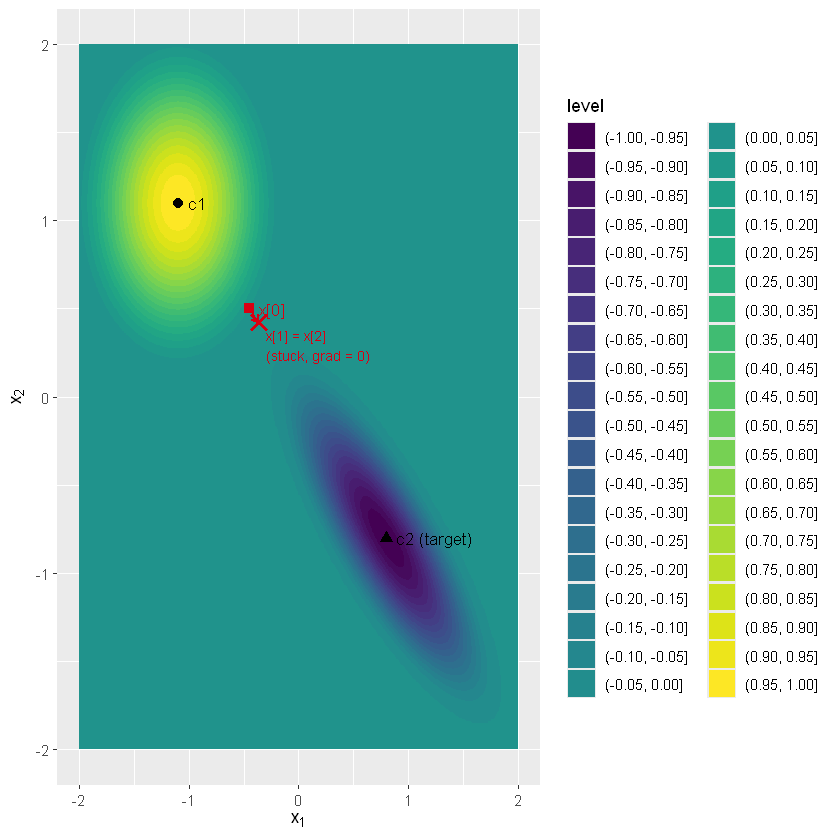

In [2]:
#| label: solution_d_code
# Gradient: leverages (b) - at any x at most ONE basin's support is active.
grad <- function(x) {
  d1_sq <- sum((x - c1)^2)
  d2_sq <- as.numeric((x - c2) %*% S2_inv %*% (x - c2))
  if (d1_sq < 1) {
    # Inside c_1 support: grad of rho(||x - c_1||)
    return(as.numeric(-4 * (1 - d1_sq) * (x - c1)))
  } else if (d2_sq < 1) {
    # Inside c_2 support; sign flipped because w_2 = -1
    return(as.numeric(4 * (1 - d2_sq) * (x - c2) %*% S2_inv))
  } else {
    return(c(0, 0))   # dead zone: gradient identically zero
  }
}

alpha <- 0.15
x0 <- c(-0.45, 0.5)
x1 <- x0 - alpha * grad(x0)
x2 <- x1 - alpha * grad(x1)

cat(sprintf("x[0] = (%+.4f, %+.4f)\n", x0[1], x0[2]))
cat(sprintf("x[1] = (%+.4f, %+.4f)\n", x1[1], x1[2]))
cat(sprintf("x[2] = (%+.4f, %+.4f)\n", x2[1], x2[2]))
cat(sprintf("grad at x[1] = (%+.4f, %+.4f)  -- identically zero -> stuck\n",
            grad(x1)[1], grad(x1)[2]))

# Visualize: arrow x[0] -> x[1], then mark the frozen point x[1] = x[2].
cont_plot +
  annotate("segment", x = x0[1], y = x0[2], xend = x1[1], yend = x1[2],
           arrow = arrow(length = unit(0.18, "cm")),
           color = "#D90012", linewidth = 0.7) +
  annotate("point", x = x1[1], y = x1[2], color = "#D90012",
           size = 3, shape = 4, stroke = 1.5) +
  annotate("text",  x = x1[1], y = x1[2],
           label = "  x[1] = x[2]\n  (stuck, grad = 0)",
           hjust = 0, vjust = 1.2, color = "#D90012", size = 3)

INSERT_solution_d_text

INSERT_problem_e

**Solution.**

INSERT_solution_e_text

INSERT_problem_f

INSERT_momentum_intuition_note

x[15] = (+0.7831, -0.7951), f = -0.9990  (target c_2 = (+0.8000, -0.8000), f = -1)


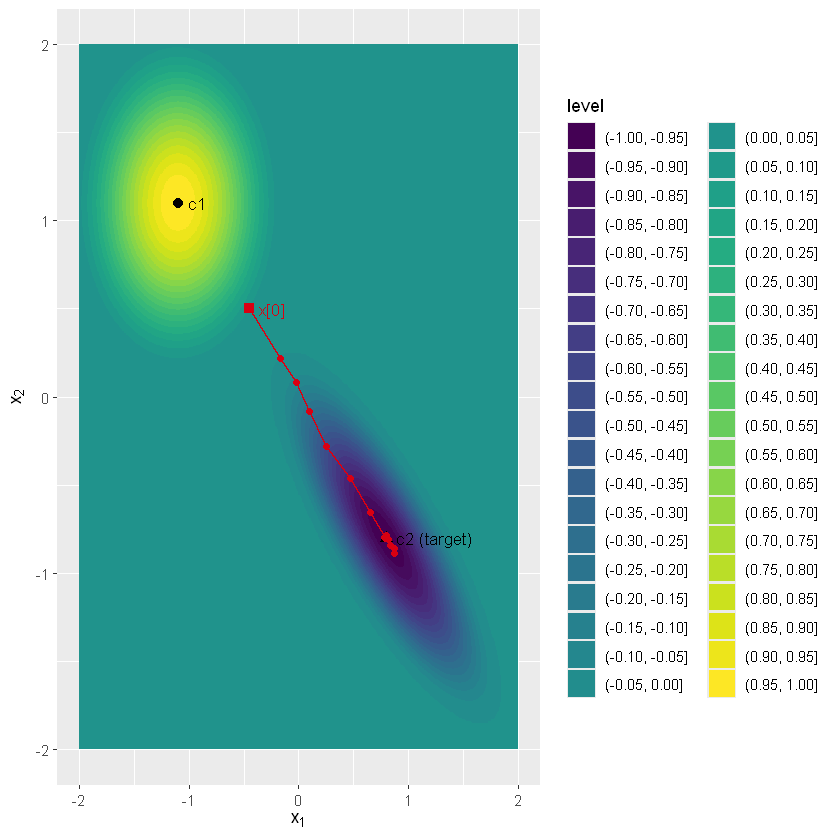

In [3]:
#| label: solution_f_code
alpha <- 0.15
phi <- 0.5
v <- c(0.4, -0.4)
x <- c(-0.45, 0.5)

xs <- x   # stack iterates for the trajectory plot
for (i in 1:15) {
  v <- phi * v - alpha * grad(x)
  x <- x + v
  xs <- rbind(xs, x)
}
rownames(xs) <- NULL
trace_df <- data.frame(xs)

cat(sprintf(paste0(
  "x[15] = (%+.4f, %+.4f), f = %+.4f  ",
  "(target c_2 = (%+.4f, %+.4f), f = -1)\n"),
            x[1], x[2], f(x), c2[1], c2[2]))

# Trajectory on the contour. cont_plot already has c1, c2, x[0] markers
# from (a); we just overlay the momentum path.
cont_plot +
  geom_path(data = trace_df, aes(x = X1, y = X2),
            color = "#D90012", linewidth = 0.6, inherit.aes = FALSE) +
  geom_point(data = trace_df, aes(x = X1, y = X2),
             color = "#D90012", size = 1.5, inherit.aes = FALSE)

INSERT_solution_f_text